In [1]:
import os
import requests

# Download a skeleton dashboard application and dataset

In [ ]:
#download files on linux OS
#Run the following wget command line in the terminal to download:
#wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"

#wget "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/t4-Vy4iOU19i8y6E3Px_ww/spacex-dash-app.py"

In [2]:
## Write the commands to download the file in the given link.
# Source dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"

# Download ans save file to 'spacex_launch_dash.csv'
path = os.path.join(os.getcwd(),'spacex_launch_dash.csv')
response = requests.get(url)
with open(path,'wb') as f:
    f.write(response.content)

In [ ]:
## Write the commands to download the file in the given link.
# Source application
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/t4-Vy4iOU19i8y6E3Px_ww/spacex-dash-app.py"

# Download ans save file to 'spacex_launch_dash.csv'
path = os.path.join(os.getcwd(),'spacex-dash-app.py')
response = requests.get(url)
with open(path,'wb') as f:
    f.write(response.content)

In [4]:
"""
## Write the commands to download the file in the given link.
# Source application
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv'

# Download ans save file to 'spacex_launch_dash.csv'
path = os.path.join(os.getcwd(),'Historical_Wildfires.csv')
response = requests.get(url)
with open(path,'wb') as f:
    f.write(response.content)
"""

In [5]:
##Test the skeleton app by running the following command in the terminal:
#python spacex-dash-app.py

In [ ]:
"""
# run file .py on Notebook
%run spacex-dash-app.py
"""

In [6]:
import pandas as pd


In [7]:
# Read the airline data into pandas dataframe
spacex_df = pd.read_csv("spacex_launch_dash.csv")
spacex_df.head()

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


In [8]:
spacex_df.shape

(56, 7)

In [9]:
spacex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                56 non-null     int64  
 1   Flight Number             56 non-null     int64  
 2   Launch Site               56 non-null     object 
 3   class                     56 non-null     int64  
 4   Payload Mass (kg)         56 non-null     float64
 5   Booster Version           56 non-null     object 
 6   Booster Version Category  56 non-null     object 
dtypes: float64(1), int64(3), object(3)
memory usage: 3.2+ KB


In [10]:
max_payload = spacex_df['Payload Mass (kg)'].max()
print(max_payload)
min_payload = spacex_df['Payload Mass (kg)'].min()
print(min_payload)

9600.0
0.0


In [11]:
spacex_df['Launch Site'].unique()

array(['CCAFS LC-40', 'VAFB SLC-4E', 'KSC LC-39A', 'CCAFS SLC-40'],
      dtype=object)

In [12]:
filtered_df = spacex_df.groupby(['Launch Site', 'class'])['class'].value_counts().reset_index(name = "total_count")
filtered_df

,Launch Site,class,total_count
0,CCAFS LC-40,0,19
1,CCAFS LC-40,1,7
2,CCAFS SLC-40,0,4
3,CCAFS SLC-40,1,3
4,KSC LC-39A,0,3
5,KSC LC-39A,1,10
6,VAFB SLC-4E,0,6
7,VAFB SLC-4E,1,4


In [13]:
type(filtered_df)

pandas.core.frame.DataFrame

In [14]:
filtered_df = spacex_df.groupby(['Launch Site', 'class'])['class'].count().reset_index(name = "total_count")
filtered_df

,Launch Site,class,total_count
0,CCAFS LC-40,0,19
1,CCAFS LC-40,1,7
2,CCAFS SLC-40,0,4
3,CCAFS SLC-40,1,3
4,KSC LC-39A,0,3
5,KSC LC-39A,1,10
6,VAFB SLC-4E,0,6
7,VAFB SLC-4E,1,4


In [15]:
# Total success
total_success = filtered_df[filtered_df['class'] == 1]
total_success

,Launch Site,class,total_count
1,CCAFS LC-40,1,7
3,CCAFS SLC-40,1,3
5,KSC LC-39A,1,10
7,VAFB SLC-4E,1,4


In [16]:
import plotly.express as px

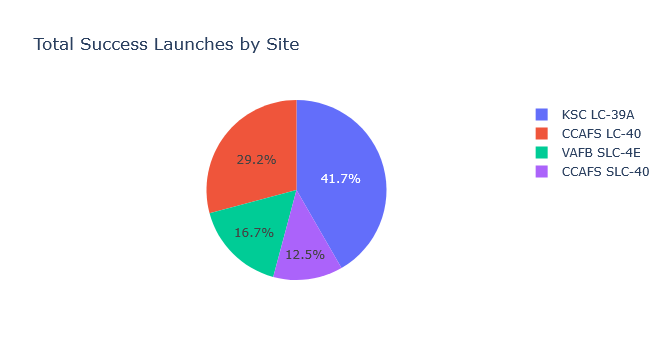

In [17]:
px.pie(total_success, values='total_count',names='Launch Site',title="Total Success Launches by Site")

In [18]:
entered_site = 'CCAFS LC-40'
site_i = filtered_df[filtered_df['Launch Site'] == entered_site]
site_i

,Launch Site,class,total_count
0,CCAFS LC-40,0,19
1,CCAFS LC-40,1,7


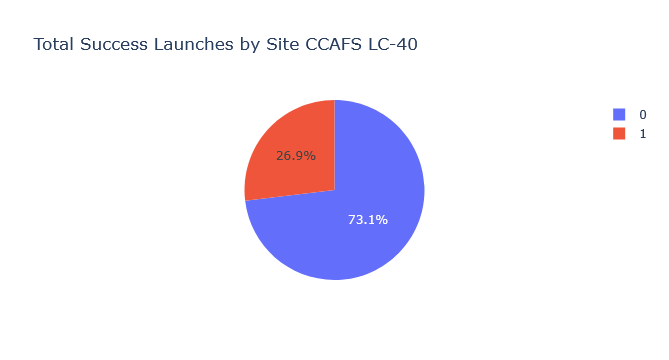

In [19]:

# if entered_site == 'CCAFS LC-40':
#entered_site = 'CCAFS LC-40'
px.pie(site_i, values='total_count',names='class',title= f"Total Success Launches by Site {entered_site}")

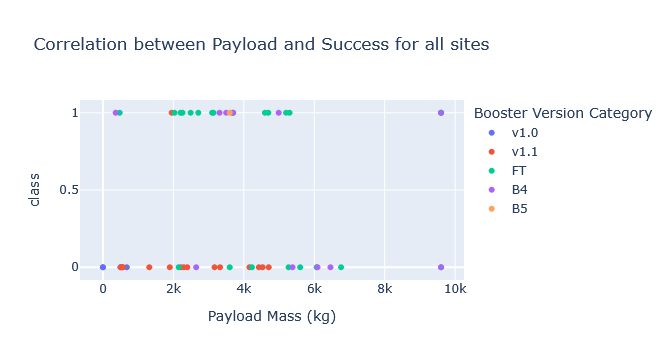

In [23]:
entered_site == 'ALL'
selected_slider = max_payload.astype('int')
selected_slider_list = list(range(0,selected_slider))
#print(selected_slider_list)
px.scatter(spacex_df, x='Payload Mass (kg)', y='class', color="Booster Version Category", title= "Correlation between Payload and Success for all sites")

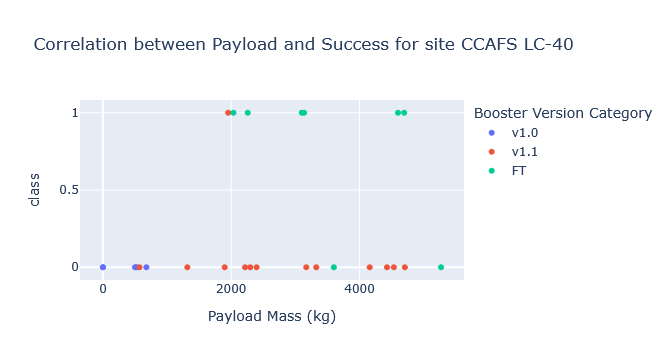

In [24]:
#entered_site != 'ALL'
entered_site = 'CCAFS LC-40'

site_i_df = spacex_df[spacex_df['Launch Site'] == entered_site]
#selected_slider = site_i_df['Payload Mass (kg)']
#print(selected_slider)

px.scatter(site_i_df, x= 'Payload Mass (kg)', y='class', color="Booster Version Category", title= f"Correlation between Payload and Success for site {entered_site}")

In [25]:
selected_slider_l = list(range(0, 10))
print(selected_slider_l )

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


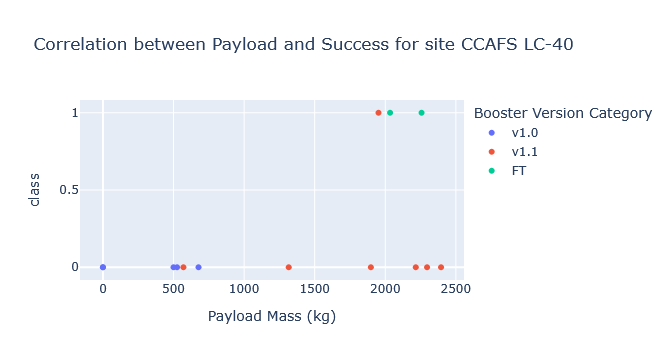

In [26]:
#entered_site != 'ALL'
entered_site = 'CCAFS LC-40'
selected_slider = 3000
selected_slider_list = list(range(0,selected_slider))
site_i_df = spacex_df[(spacex_df['Launch Site'] == entered_site) & (spacex_df['Payload Mass (kg)'].isin(selected_slider_list))]
#selected_slider = site_i_df['Payload Mass (kg)']
#print(selected_slider)

px.scatter(site_i_df, x= 'Payload Mass (kg)', y='class', color="Booster Version Category", title= f"Correlation between Payload and Success for site {entered_site}")

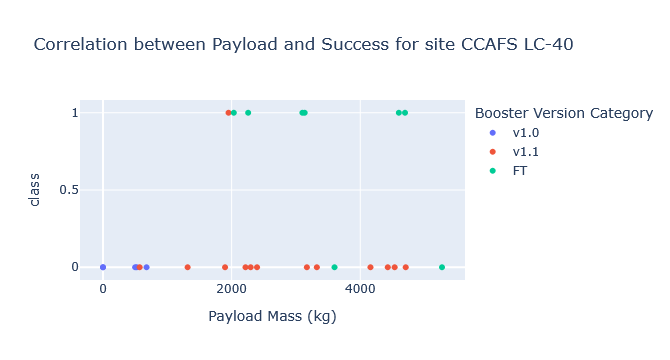

In [35]:
#entered_site != 'ALL'
entered_site = 'CCAFS LC-40'
selected_slider = [0, 7000]
#selected_slider_list = list(range(selected_slider[0], selected_slider[1] ))
selected_slider_range = range(selected_slider[0], selected_slider[1] )
site_i_df = spacex_df[(spacex_df['Launch Site'] == entered_site) & (spacex_df['Payload Mass (kg)'].isin(selected_slider_range))]
#selected_slider = site_i_df['Payload Mass (kg)']
#print(selected_slider)

px.scatter(site_i_df, x= 'Payload Mass (kg)', y='class', color="Booster Version Category", title= f"Correlation between Payload and Success for site {entered_site}")